Reference: https://huggingface.co/spaces/praan/qdrant-llm-query-answering

In [1]:
!pip install tiktoken
!pip install langchain
!pip install openai==0.28
!pip install PyPDF2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 13.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 810.5/810.5 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 19.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 273.9/273.9 kB 21.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.9/86.9 kB 10.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.4/49.4 kB 5.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 7.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.8/144.8 kB 21.5 MB/s eta 0:00:00
  Attempting uninstall: packaging
    Found existing installation: packaging 24.0
    Uninstalling packaging-24.0:
      Successfully uninstalled packaging-24.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.5/76.5 kB 1.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 232.6/232.6 kB 6.0 MB/s eta 0:00:00


In [2]:
!pip install qdrant_client

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 5.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 75.6/75.6 kB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB 24.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 10.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 8.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.3/58.3 kB 8.3 MB/s eta 0:00:00
  Attempting uninstall: protobuf
    Found existing installation: protobuf 3.20.3
    Uninstalling protobuf-3.20.3:
      Successfully uninstalled protobuf-3.20.3
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorflow-metadata 1.14.0 requires protobuf<4.21,>=3.20.3, but you have protobuf 4.25.3 which i

In [3]:
from PyPDF2 import PdfReader
from langchain.text_splitter import CharacterTextSplitter
from langchain.vectorstores import Qdrant
from langchain.embeddings import OpenAIEmbeddings
from qdrant_client import QdrantClient,models
from qdrant_client.http.models import PointStruct
import os
import uuid
import openai

In [4]:
import requests
import tempfile


In [5]:
record = 0


from qdrant_client import QdrantClient

connection = QdrantClient(
    url="https://40535b3f-d117-49dd-8bdc-6fb826edc0c6.us-east4-0.gcp.cloud.qdrant.io:6333",
    api_key="-7PSR7d60KlZ5SlCaHThUM-yST1aGm24lPP0xs9uIkqYn8o85-cRAw",
)

In [6]:
collection_name = "extractive-question-answering"

In [7]:
connection.recreate_collection(
    collection_name = "extractive-question-answering",
    vectors_config = models.VectorParams(size=768, distance = models.Distance.COSINE)
)

True

In [8]:
print("Create collection response:", connection)

Create collection response: <qdrant_client.qdrant_client.QdrantClient object at 0x7afb4297cbb0>


In [9]:
info = connection.get_collection(collection_name = "extractive-question-answering")


In [10]:
print("Collection info:", info)

Collection info: status=<CollectionStatus.GREEN: 'green'> optimizer_status=<OptimizersStatusOneOf.OK: 'ok'> vectors_count=0 indexed_vectors_count=0 points_count=0 segments_count=2 config=CollectionConfig(params=CollectionParams(vectors=VectorParams(size=768, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_optimization_threads=None), wal_config=WalConfig(wal_capacity_mb=32, wal_segments_ahead=0), quantization_config=None) payload_schema={}


In [11]:
for get_info in info:
  print(get_info)

('status', <CollectionStatus.GREEN: 'green'>)
('optimizer_status', <OptimizersStatusOneOf.OK: 'ok'>)
('vectors_count', 0)
('indexed_vectors_count', 0)
('points_count', 0)
('segments_count', 2)
('config', CollectionConfig(params=CollectionParams(vectors=VectorParams(size=768, distance=<Distance.COSINE: 'Cosine'>, hnsw_config=None, quantization_config=None, on_disk=None), shard_number=1, sharding_method=None, replication_factor=1, write_consistency_factor=1, read_fan_out_factor=None, on_disk_payload=True, sparse_vectors=None), hnsw_config=HnswConfig(m=16, ef_construct=100, full_scan_threshold=10000, max_indexing_threads=0, on_disk=False, payload_m=None), optimizer_config=OptimizersConfig(deleted_threshold=0.2, vacuum_min_vector_number=1000, default_segment_number=0, max_segment_size=None, memmap_threshold=None, indexing_threshold=20000, flush_interval_sec=5, max_optimization_threads=None), wal_config=WalConfig(wal_capacity_mb=32, wal_segments_ahead=0), quantization_config=None))
('payloa

In [12]:
!pip install -qqq plotly sentence-transformers

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.3/163.3 kB 5.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 40.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 64.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 93.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 731.7/731.7 MB 1.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 1.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 8.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 12.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 8.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 6.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 MB 7.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.1/99.1 kB 13.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━

In [13]:
from sentence_transformers import SentenceTransformer

In [14]:
model = SentenceTransformer('all-mpnet-base-v2', device="cuda")

/usr/local/lib/python3.10/dist-packages/huggingface_hub/utils/_token.py:88: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.6k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

1_Pooling/config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [15]:
import pandas as pd

In [17]:
df = pd.read_csv('./bigBasketProducts.csv')

In [18]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27555 entries, 0 to 27554
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   index         27555 non-null  int64  
 1   product       27554 non-null  object 
 2   category      27555 non-null  object 
 3   sub_category  27555 non-null  object 
 4   brand         27554 non-null  object 
 5   sale_price    27555 non-null  float64
 6   market_price  27555 non-null  float64
 7   type          27555 non-null  object 
 8   rating        18929 non-null  float64
 9   description   27440 non-null  object 
dtypes: float64(3), int64(1), object(6)
memory usage: 2.1+ MB


In [19]:
df.head()

,index,product,category,sub_category,brand,sale_price,market_price,type,rating,description
0,1,Garlic Oil - Vegetarian Capsule 500 mg,Beauty & Hygiene,Hair Care,Sri Sri Ayurveda,220.0,220.0,Hair Oil & Serum,4.1,This Product contains Garlic Oil that is known...
1,2,Water Bottle - Orange,"Kitchen, Garden & Pets",Storage & Accessories,Mastercook,180.0,180.0,Water & Fridge Bottles,2.3,"Each product is microwave safe (without lid), ..."
2,3,"Brass Angle Deep - Plain, No.2",Cleaning & Household,Pooja Needs,Trm,119.0,250.0,Lamp & Lamp Oil,3.4,"A perfect gift for all occasions, be it your m..."
3,4,Cereal Flip Lid Container/Storage Jar - Assort...,Cleaning & Household,Bins & Bathroom Ware,Nakoda,149.0,176.0,"Laundry, Storage Baskets",3.7,Multipurpose container with an attractive desi...
4,5,Creme Soft Soap - For Hands & Body,Beauty & Hygiene,Bath & Hand Wash,Nivea,162.0,162.0,Bathing Bars & Soaps,4.4,Nivea Creme Soft Soap gives your skin the best...


In [20]:
print(set(df["product"]))

{'Motomax Dashboard Polish', 'Oven Cake Mix - Vanilla', 'Yellow Cloth - Small', 'Organic - Tomato Powder Dehydrated', 'Snack Pack - Strawberry With chunky Granola', 'Kara Boondhi', 'Natural Cranberry Coffee Body Scrub', 'Fresh Fruit Massage Cream - With Apple, Orange, Papaya & Kokum Butter', 'Tongue Cleaner - Copper 004', '360 Degree Whole Mouth Clean Soft Bristle Toothbrush', 'Gliss Hair Repair Conditioner Color Protect & Shine', 'Tomato Knife - Swift', 'Vertes Corner Rack - Small, Assorted Colour', 'Biscuits - Marie', 'Cheela Mix - Multi Millet, Gluten Free', 'Wasabi Paste', 'Ultralights Highlighting Kit - Coffee Collection, Mocha Brown', 'Moisturising Baby Lotion With Fruit Extracts', 'Deltoid Turbo Face Masks In Navy Mesh With Blue, Grey & Navy Bindings - Assorted, 3C2003, Medium', 'Awadhi Lazzat Ul Taam/Potli Ka Masala', 'Power Toothbrush For Kids - Yellow', 'Kitchen Moppy', 'Chocolate Flavoured Lubes', 'Chocolate - Milk', 'I Love You 365 Of The Days Signature Chocolate Bar', 'Roa

In [21]:
len(set(df["product"]))

23541

In [22]:
print(set(df["category"]))
print(len(set(df["category"])))

{'Cleaning & Household', 'Gourmet & World Food', 'Snacks & Branded Foods', 'Fruits & Vegetables', 'Eggs, Meat & Fish', 'Foodgrains, Oil & Masala', 'Kitchen, Garden & Pets', 'Bakery, Cakes & Dairy', 'Beverages', 'Baby Care', 'Beauty & Hygiene'}
11


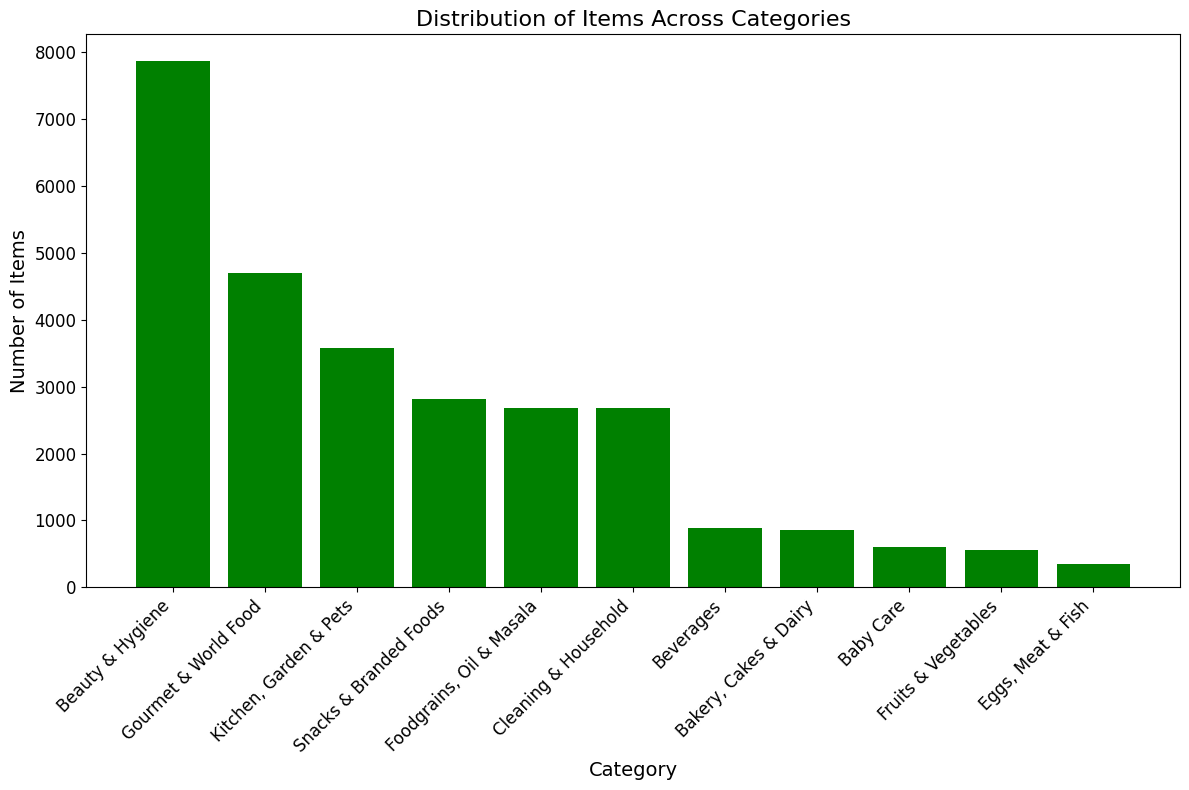

In [23]:
import pandas as pd
import matplotlib.pyplot as plt


# Calculate counts of items in each sub-category
category_counts = df["category"].value_counts()

# Plotting
plt.figure(figsize=(12, 8))  # Set the figure size for better readability
plt.bar(category_counts.index, category_counts.values, color='green')  # Create a bar chart
plt.xlabel('Category', fontsize=14)  # Label for X-axis
plt.ylabel('Number of Items', fontsize=14)  # Label for Y-axis
plt.xticks(rotation=45, ha="right", fontsize=12)  # Rotate the X-axis labels for better readability
plt.yticks(fontsize=12)
plt.title('Distribution of Items Across Categories', fontsize=16)  # Title of the plot
plt.tight_layout()  # Automatically adjust subplot parameters to give specified padding
plt.show()


In [24]:
print(set(df["sub_category"]))
print(len(set(df["sub_category"])))

{'Stationery', 'Oils & Vinegar', 'Cereals & Breakfast', 'Chocolates & Candies', 'Baby Accessories', 'Marinades', 'Feminine Hygiene', 'Bakeware', 'Ice Creams & Desserts', 'Eggs', 'Organic Staples', 'Drinks & Beverages', 'Breads & Buns', 'Ready To Cook & Eat', 'Fresheners & Repellents', 'Dairy & Cheese', 'Baby Food & Formula', 'Diapers & Wipes', 'Rice & Rice Products', 'Skin Care', 'Fresh Vegetables', 'Spreads, Sauces, Ketchup', 'Kitchen Accessories', 'Pet Food & Accessories', 'Health & Medicine', 'Snacks & Namkeen', 'Car & Shoe Care', 'Frozen Veggies & Snacks', 'Makeup', 'Non Dairy', 'Biscuits & Cookies', 'Breakfast Cereals', 'Water', 'Edible Oils & Ghee', 'Feeding & Nursing', 'Oral Care', 'Gardening', 'Noodle, Pasta, Vermicelli', 'Steel Utensils', 'Crockery & Cutlery', 'Dairy', 'Bath & Hand Wash', 'Sauces, Spreads & Dips', 'Cooking & Baking Needs', 'Snacks, Dry Fruits, Nuts', 'Tea', 'Flask & Casserole', 'All Purpose Cleaners', 'Atta, Flours & Sooji', 'Fruit Juices & Drinks', 'Cakes & P

In [25]:
import plotly.express as px

sub_category_counts = df["sub_category"].value_counts()

# Create an interactive bar chart with Plotly
fig = px.bar(sub_category_counts,
             x=sub_category_counts.index,
             y=sub_category_counts.values,
             title='Interactive Distribution of Items Across Sub-Categories',
             labels={'y': 'Number of Items', 'index': 'Sub-Category'},
             color=sub_category_counts.values,
             color_continuous_scale=px.colors.sequential.Viridis)

# Improve the layout
fig.update_layout(xaxis_tickangle=-45,  # Rotate labels
                  xaxis_title='Sub-Category',
                  yaxis_title='Number of Items',
                  coloraxis_showscale=False)  # Hide the color scale if not needed

# Show the figure
fig.show()


In [26]:
print(set(df["type"]))
print(len(set(df["type"])))

{'Dishwash Liquids & Pastes', 'Aerated, Still, Sparkling', 'Gingelly Oil', 'Books & Magazines', 'Bathing Bars & Soaps', 'Prawns & Shrimps', 'Imported Cleaners', 'Car Freshener', 'Glucose Powder, Tablets', 'Roses', 'Health Drinks', 'Tea Bags', 'Cookies', 'Other Flowers', 'Perfume', 'Face Masks & Safety Gears', 'Granola & Cereal Bars', 'Talcum Powder', 'Pastas & Spaghetti', 'Cream & Cheese Spreads', 'Umbrella', 'Curry Paste, Coconut Milk', 'Baby Oral Care', 'Nappies & Rash Cream', 'Insect Repellent', 'Children (2-5 Yrs)', 'Lemon, Ginger & Garlic', 'Shampoo & Conditioner', 'Eau De Parfum', 'Cooking Chocolate, Cocoa', 'Cookies, Biscotti, Wafer', 'Bathing Accessories', 'Kadai & Fry Pans', 'Toffee, Candy & Lollypop', 'Steel Lunch Boxes', 'Rice & Other Flours', 'Casserole', 'Aromatherapy', 'Herbs, Seasonings & Rubs', 'Beans & Pulses', 'Kiwi, Melon, Citrus Fruit', 'Organic Dry Fruits', 'Imported Soups', 'Boiled & Steam Rice', 'Banana, Sapota & Papaya', 'Jams, Marmalade, Spreads', 'Vacuum Flask

In [27]:
# Calculate counts of items in each 'type'
type_counts = df["type"].value_counts()

# Create an interactive bar chart with Plotly Express
fig = px.bar(type_counts,
             x=type_counts.index,
             y=type_counts.values,
             title='Interactive Distribution of Different Types of Items',
             labels={'y': 'Number of Items', 'index': 'Type'},
             color=type_counts.values,
             color_continuous_scale=px.colors.sequential.Viridis)

# Improve the layout
fig.update_layout(
    xaxis_tickangle=-45,  # Rotate labels
    xaxis_title='Type',
    yaxis_title='Number of Items',
    coloraxis_showscale=False  # Hide the color scale if not needed
)

# Show the figure
fig.show()

In [28]:
headers = [h for h in df.columns]

In [29]:
headers

['index',
 'product',
 'category',
 'sub_category',
 'brand',
 'sale_price',
 'market_price',
 'type',
 'rating',
 'description']

In [30]:
items = []
for row in df.itertuples():
  string = ''
  for i in range(len(headers)):
    string += headers[i] + ': ' + str(row[i]) + '; '
  items.append(string)

In [31]:
vectors = model.encode(items, show_progress_bar=True)

Batches:   0%|          | 0/862 [00:00<?, ?it/s]

In [32]:
vectors.shape

(27555, 768)

In [33]:
from tqdm import tqdm  # Import the tqdm function

batch_size = 512  # specify batch size according to your RAM and compute, higher batch size = more RAM usage

for index in tqdm(range(0, len(df), batch_size)):
    df.fillna('', inplace=True)
    i_end = min(index + batch_size, len(df))  # find end of batch
    batch = df.iloc[index:i_end]  # extract batch
    emb = vectors[index:i_end].tolist() # generate embeddings for batch

    meta = batch.to_dict(orient="records")  # get metadata
    ids = list(range(index, i_end))  # create unique IDs
    # upsert to qdrant
    connection.upsert(
        collection_name="extractive-question-answering",
        points=models.Batch(ids=ids, vectors=emb, payloads=meta),
    )

collection_vector_count = connection.get_collection(collection_name="extractive-question-answering").vectors_count
print(f"Vector count in collection: {collection_vector_count}")
#


100%|██████████| 54/54 [00:55<00:00,  1.03s/it]

Vector count in collection: 42636


In [34]:
assert collection_vector_count == len(df)

AssertionError: 

In [35]:
model_name = "bert-large-uncased-whole-word-masking-finetuned-squad"
from transformers import pipeline

# load the reader model into a question-answering pipeline
reader = pipeline("question-answering", model=model_name, tokenizer=model_name)
print(reader.model, reader)

config.json:   0%|          | 0.00/443 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.34G [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-large-uncased-whole-word-masking-finetuned-squad were not used when initializing BertForQuestionAnswering: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForQuestionAnswering from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForQuestionAnswering from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

BertForQuestionAnswering(
  (bert): BertModel(
    (embeddings): BertEmbeddings(
      (word_embeddings): Embedding(30522, 1024, padding_idx=0)
      (position_embeddings): Embedding(512, 1024)
      (token_type_embeddings): Embedding(2, 1024)
      (LayerNorm): LayerNorm((1024,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (encoder): BertEncoder(
      (layer): ModuleList(
        (0-23): 24 x BertLayer(
          (attention): BertAttention(
            (self): BertSelfAttention(
              (query): Linear(in_features=1024, out_features=1024, bias=True)
              (key): Linear(in_features=1024, out_features=1024, bias=True)
              (value): Linear(in_features=1024, out_features=1024, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): BertSelfOutput(
              (dense): Linear(in_features=1024, out_features=1024, bias=True)
              (LayerNorm): LayerNorm((1024,), ep

In [36]:
from typing import List

In [37]:
def get_context(question: str, top_k: int, progress_bar) -> List[str]:
    """
    Get the relevant plot for a given question

    Args:
        question (str): What do we want to know?
        top_k (int): Top K results to return

    Returns:
        context (List[str]):
    """
    try:
        encoded_query = model.encode(question).tolist()  # generate embeddings for the question

        result = connection.search(
            collection_name=collection_name,
            query_vector=encoded_query,
            limit=top_k,
        )  # search qdrant collection for context passage with the answer

        context = [
            [x.payload] for x in result
        ]  # extract title and payload from result
        progress_bar.update(1)
        return context

    except Exception as e:
        print({e})
        progress_bar.update(1)

In [38]:
def extract_answer(question: str, context: List[str], progress_bar):
    """
    Extract the answer from the context for a given question

    Args:
        question (str): _description_
        context (list[str]): _description_
    """
    results = []
    for c in context:
        # feed the reader the question and contexts to extract answers
        string = ''
        for i in range(len(headers)):
          string += headers[i] + ': ' + str(c[0][headers[i]]) + '; '
        answer = reader(question=question, context = string)
        answer["title"] = c[0]['index']
        results.append(answer)
        progress_bar.update(1)

    # sort the result based on the score from reader model
    sorted_result = sorted(results, key=lambda x: x["score"], reverse=True)
    return sorted_result

In [39]:
def display_answer(query):
  progress_bar = tqdm(total=12, desc='Processing', leave=False)
  context = get_context(query,10, progress_bar)
  result = extract_answer(query, context, progress_bar)
  string = ''
  for i in range(5):
    if result[i]["answer"] not in string:
      if i==0: string += result[i]["answer"] + f'[{result[i]["title"]}]'
      else: string += ', ' + result[i]["answer"] + f'[{result[i]["title"]}]'
  progress_bar.update(1)
  progress_bar.close()
  string += '.'
  return string

In [40]:
display_answer("which item was sold the most?")

'Newyork Deodorant Spray[1870], Super Set for Women[8748], Gift Sets[3823], Candy Jar[9911], Disney Mickey Mouse[3532].'